# EE 446 TinyML — Model Pruning with Quantization  
## Student TODO Version: Pruning and Quantization of a DNN Using the UCI Human Activity Recognition Dataset

### Overview
In this notebook, you will:
- train a baseline DNN on the **UCI HAR** dataset,
- apply **magnitude-based pruning**,
- compare the pruned model before and after `strip_pruning(...)`, and
- combine pruning with **float16 quantization**.

Use the **`Python (tinyml-arduino)`** Jupyter kernel for this notebook.


## 1. Environment Setup

This notebook is designed to run with the **`Python (tinyml-arduino)`** Jupyter kernel that you already created.

This notebook assumes the environment already contains:
- `tensorflow==2.14.1`
- `tensorflow-model-optimization==0.8.0`
- `numpy`, `pandas`, `matplotlib`, and `scikit-learn`

Do **not** reinstall TensorFlow packages inside the notebook if you are already using the working TinyML environment.


In [37]:
import os
import math
import zipfile
import random
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Python executable:", os.sys.executable)
print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


Python executable: C:\Users\spappuru\tinyml-arduino\Scripts\python.exe
TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 2. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals,
- **6 activity classes**, and
- predefined **training** and **test** splits.

The code below downloads and extracts the dataset if it is not already present in the working directory.


In [38]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    urllib.request.urlretrieve(dataset_url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 3. Load the Data

In [39]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt as float32
    # 2. Load y_train from train/y_train.txt as int32
    # 3. Load X_test from test/X_test.txt as float32
    # 4. Load y_test from test/y_test.txt as int32
    # 5. Convert labels to zero-based class indices by subtracting 1
    X_train = np.loadtxt(os.path.join(root_dir, "train", "X_train.txt"), dtype=np.float32)
    y_train = np.loadtxt(os.path.join(root_dir, "train", "y_train.txt"), dtype=np.int32) - 1
    X_test  = np.loadtxt(os.path.join(root_dir, "test",  "X_test.txt"),  dtype=np.float32)
    y_test  = np.loadtxt(os.path.join(root_dir, "test",  "y_test.txt"),  dtype=np.int32) - 1
    # <-- Enter your code here <--#
    return X_train, y_train, X_test, y_test
    
X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO:
# Define num_features and num_classes.
# Print the train/test shapes and the number of features/classes.
# <-- Enter your code here <--#
num_features = X_train.shape[1]
num_classes  = len(class_names)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"y_test  shape: {y_test.shape}")
print(f"num_features : {num_features}")
print(f"num_classes  : {num_classes}")

X_train shape: (7352, 561)
y_train shape: (7352,)
X_test  shape: (2947, 561)
y_test  shape: (2947,)
num_features : 561
num_classes  : 6


## 4. Quick Inspection

In [40]:
# TODO:
# Create a small summary table showing:
# - class index,
# - class name, and
# - number of training samples in each class.

# <-- Enter your code here <--#
unique, counts = np.unique(y_train, return_counts=True)
summary_df = pd.DataFrame({
    "Class Index":   unique,
    "Class Name":    [class_names[i] for i in unique],
    "Train Samples": counts,
})
print(summary_df.to_string(index=False))

 Class Index         Class Name  Train Samples
           0            WALKING           1226
           1   WALKING_UPSTAIRS           1073
           2 WALKING_DOWNSTAIRS            986
           3            SITTING           1286
           4           STANDING           1374
           5             LAYING           1407


## 5. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [41]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    # <-- Enter your code here <--#
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64,  activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model 
baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_8 (Dense)             (None, 256)               143872    
                                                                 
 dense_9 (Dense)             (None, 128)               32896     
                                                                 
 dense_10 (Dense)            (None, 64)                8256      
                                                                 
 dense_11 (Dense)            (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model

In [42]:
# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/40
92/92 [==============================] - 1s 3ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1640 - accuracy: 0.9367 - val_loss: 0.1402 - val_accuracy: 0.9381
Epoch 3/40
92/92 [==============================] - 0s 2ms/step - loss: 0.1165 - accuracy: 0.9561 - val_loss: 0.2180 - val_accuracy: 0.9259
Epoch 4/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0886 - accuracy: 0.9641 - val_loss: 0.1500 - val_accuracy: 0.9402
Epoch 5/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0885 - accuracy: 0.9645 - val_loss: 0.2037 - val_accuracy: 0.9218
Epoch 6/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0769 - accuracy: 0.9696 - val_loss: 0.2337 - val_accuracy: 0.9252
Epoch 7/40
92/92 [==============================] - 0s 2ms/step - loss: 0.0735 - accuracy: 0.9731 - val_loss: 0.1396 - val_accuracy: 0.9449
Epoch 8/40
92/92 [==

### Training Curves

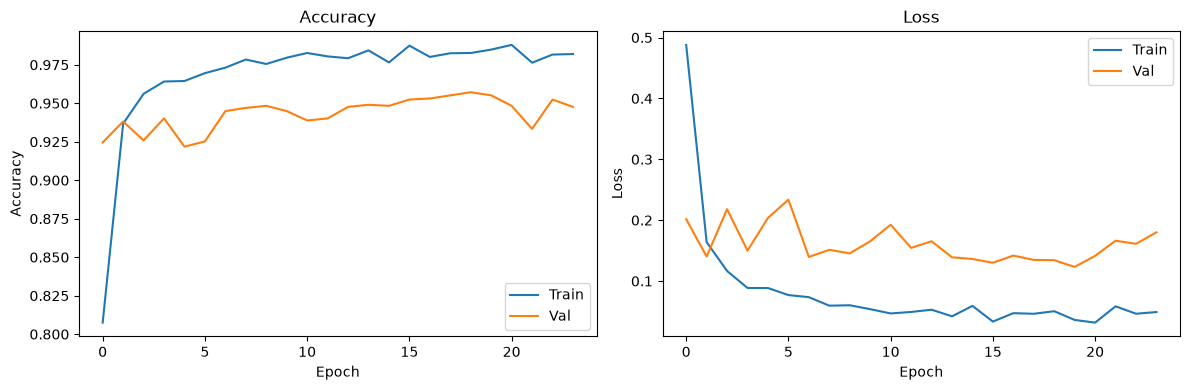

In [43]:
# TODO:
# Plot:
# 1. training accuracy vs validation accuracy
# 2. training loss vs validation loss

# <-- Enter your code here <--#
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(baseline_history.history["accuracy"],     label="Train")
axes[0].plot(baseline_history.history["val_accuracy"], label="Val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy")
axes[0].legend()

axes[1].plot(baseline_history.history["loss"],     label="Train")
axes[1].plot(baseline_history.history["val_loss"], label="Val")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Evaluate the Baseline Keras Model

Baseline Keras Test Accuracy: 0.9399

                    precision    recall  f1-score   support

           WALKING     0.9278    0.9839    0.9550       496
  WALKING_UPSTAIRS     0.9198    0.9490    0.9342       471
WALKING_DOWNSTAIRS     0.9841    0.8857    0.9323       420
           SITTING     0.9412    0.8798    0.9095       491
          STANDING     0.8829    0.9492    0.9149       532
            LAYING     1.0000    0.9795    0.9897       537

          accuracy                         0.9399      2947
         macro avg     0.9426    0.9379    0.9392      2947
      weighted avg     0.9418    0.9399    0.9399      2947



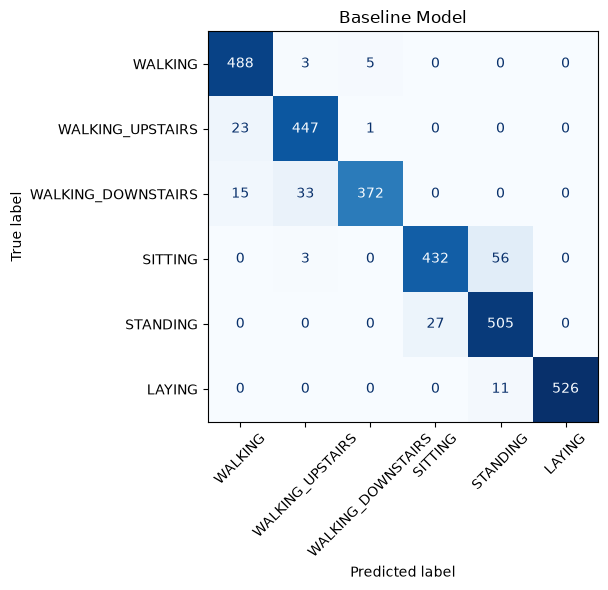

In [44]:
# TODO:
# 1. Predict class probabilities on X_test
# 2. Convert probabilities to class labels using argmax
# 3. Compute the test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

# <-- Enter your code here <--#
baseline_probs = baseline_model.predict(X_test, verbose=0)
baseline_preds = np.argmax(baseline_probs, axis=1)
baseline_acc   = accuracy_score(y_test, baseline_preds)

print(f"Baseline Keras Test Accuracy: {baseline_acc:.4f}\n")
print(classification_report(y_test, baseline_preds, target_names=class_names, digits=4))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, baseline_preds),
    display_labels=class_names
).plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
ax.set_title("Baseline Model")
plt.tight_layout()
plt.show()

# Part I: Model Pruning with Sparsity

In this part, we apply **magnitude-based pruning** to the DNN. The key idea is to gradually set small-magnitude weights to zero during training.

We will compare:
1. the baseline TensorFlow Lite model,
2. the pruned model converted **without** stripping the pruning wrappers, and
3. the stripped sparse model converted with **experimental sparsity-aware optimization**.


## 7. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model size.


In [45]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    input_dtype  = input_details["dtype"]  
    output_dtype = output_details["dtype"] 

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the TFLite input tensor expects int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.

        # <-- Enter your code here <--#
        if input_dtype in (np.int8, np.uint8):
            x = np.round(x / input_scale + input_zero_point).astype(input_dtype)
        else:
            x = x.astype(np.float32)

        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # Dequantize the output only when the output tensor is int8 or uint8.

        # <-- Enter your code here <--#
        if output_dtype in (np.int8, np.uint8):
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        pred = int(np.argmax(output, axis=1)[0])
        y_pred.append(pred)

    acc = accuracy_score(y_true, y_pred)
    return acc, np.array(y_pred)

def convert_to_tflite_fp32(model):
    # TODO:
    # Create a TFLiteConverter from the Keras model and return the converted FP32 model bytes.
    import tempfile
    with tempfile.TemporaryDirectory() as tmp_dir:
        model.export(tmp_dir)
        converter = tf.lite.TFLiteConverter.from_saved_model(tmp_dir)
        tflite_model = converter.convert()
    assert tflite_model is not None, "TFLite conversion returned None"
    return tflite_model

## 8. Convert the Baseline Model to TensorFlow Lite

In [46]:
# TODO:
# Convert the baseline model to FP32 TensorFlow Lite.
# Save the .tflite file, compute its size in KB, and evaluate it on X_test.

# <-- Enter your code here <--#
baseline_fp32_tflite  = convert_to_tflite_fp32(baseline_model)
baseline_fp32_size_kb = save_binary_model(baseline_fp32_tflite, "baseline_fp32.tflite")
baseline_fp32_acc, _  = evaluate_tflite_model(baseline_fp32_tflite, X_test, y_test)

print(f"Baseline FP32 TFLite Accuracy : {baseline_fp32_acc:.4f}")
print(f"Baseline FP32 TFLite Size (KB): {baseline_fp32_size_kb:.2f}")

INFO:tensorflow:Assets written to: C:\Users\spappuru\AppData\Local\Temp\tmpwdlv6qsf\assets


INFO:tensorflow:Assets written to: C:\Users\spappuru\AppData\Local\Temp\tmpwdlv6qsf\assets


Saved artifact at 'C:\Users\spappuru\AppData\Local\Temp\tmpwdlv6qsf'. The following endpoints are available:

* Endpoint 'serve'
  Args:
    args_0: float32 Tensor, shape=(None, 561)
  Returns:
    float32 Tensor, shape=(None, 6)
Baseline FP32 TFLite Accuracy : 0.9399
Baseline FP32 TFLite Size (KB): 726.77


## 9. Apply Magnitude-Based Pruning

We will prune the DNN using a **polynomial decay schedule**:
- start from low sparsity,
- gradually increase sparsity during training, and
- finish with a highly sparse model.

After training, we will compare:
- the pruned model **with** the pruning wrappers still present, and
- the final sparse model after applying `strip_pruning(...)`.


In [47]:
from tensorflow_model_optimization.sparsity.keras import (
    prune_low_magnitude,
    PolynomialDecay,
    UpdatePruningStep,
    strip_pruning
)

pruning_epochs = 12
batch_size = 64

# TODO:
# Compute steps_per_epoch using 80% of the training set and the selected batch size.
# Define pruning_params using PolynomialDecay with:
# - initial_sparsity=0.20
# - final_sparsity=0.85
# - begin_step=0
# - end_step=steps_per_epoch * pruning_epochs

# <-- Enter your code here <--#
num_train_samples = int(X_train.shape[0] * 0.8)
steps_per_epoch   = math.ceil(num_train_samples / batch_size)
end_step          = steps_per_epoch * pruning_epochs

# TODO:
# Create the pruned model by wrapping a fresh baseline DNN with prune_low_magnitude.
# Compile it with Adam(1e-3), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#
print(f"steps_per_epoch : {steps_per_epoch}")
print(f"end_step        : {end_step}")

pruning_params = {
    "pruning_schedule": PolynomialDecay(
        initial_sparsity=0.20,
        final_sparsity=0.85,
        begin_step=0,
        end_step=end_step,
    )
}

pruned_model = prune_low_magnitude(
    build_baseline_model(num_features, num_classes),
    **pruning_params
)
pruned_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
pruned_model.summary()

pruning_callbacks = [
    UpdatePruningStep(),
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=3,
        restore_best_weights=True
    )
]

# TODO:
# Train the pruned model using:
# - validation_split=0.2
# - epochs=pruning_epochs
# - batch_size=batch_size
# - callbacks=pruning_callbacks

# <-- Enter your code here <--#
pruning_history = pruned_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=pruning_epochs,
    batch_size=batch_size,
    callbacks=pruning_callbacks,
    verbose=1,
)

steps_per_epoch : 92
end_step        : 1104
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 prune_low_magnitude_dense_  (None, 256)               287490    
 12 (PruneLowMagnitude)                                          
                                                                 
 prune_low_magnitude_dense_  (None, 128)               65666     
 13 (PruneLowMagnitude)                                          
                                                                 
 prune_low_magnitude_dense_  (None, 64)                16450     
 14 (PruneLowMagnitude)                                          
                                                                 
 prune_low_magnitude_dense_  (None, 6)                 776       
 15 (PruneLowMagnitude)                                          
                                                                 
Total para

## 10. Convert the Pruned Model Before and After Stripping the Pruning Wrappers

First, we convert the pruned model **with** the pruning wrappers still attached.

Next, we strip the pruning wrappers and convert the resulting sparse model with:
- `tf.lite.Optimize.EXPERIMENTAL_SPARSITY`

This is the proper way to preserve sparsity in the exported TensorFlow Lite model.


In [48]:
# TODO:
# 1. Convert the pruned model WITH the pruning wrappers still attached to FP32 TensorFlow Lite.
# 2. Save the model and evaluate it on X_test.
# 3. Strip the pruning wrappers using strip_pruning(...).
# 4. Convert the stripped model with tf.lite.Optimize.EXPERIMENTAL_SPARSITY.
# 5. Save the stripped sparse model and evaluate it on X_test.

# <-- Enter your code here <--#
pruned_with_mask_tflite  = convert_to_tflite_fp32(pruned_model)
pruned_with_mask_size_kb = save_binary_model(pruned_with_mask_tflite, "pruned_with_mask_fp32.tflite")
pruned_with_mask_acc, pruned_with_mask_preds = evaluate_tflite_model(
    pruned_with_mask_tflite, X_test, y_test
)

stripped_model = strip_pruning(pruned_model)
stripped_model.summary()

converter = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
converter.optimizations = [tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
stripped_sparse_tflite = converter.convert()

stripped_sparse_size_kb = save_binary_model(stripped_sparse_tflite, "stripped_sparse_fp32.tflite")
stripped_sparse_acc, stripped_sparse_preds = evaluate_tflite_model(
    stripped_sparse_tflite, X_test, y_test
)

print(f"Pruned with mask  — Accuracy: {pruned_with_mask_acc:.4f},  Size: {pruned_with_mask_size_kb:.2f} KB")
print(f"Stripped sparse   — Accuracy: {stripped_sparse_acc:.4f},  Size: {stripped_sparse_size_kb:.2f} KB")

INFO:tensorflow:Assets written to: C:\Users\spappuru\AppData\Local\Temp\tmpyysqdq9z\assets


INFO:tensorflow:Assets written to: C:\Users\spappuru\AppData\Local\Temp\tmpyysqdq9z\assets


Saved artifact at 'C:\Users\spappuru\AppData\Local\Temp\tmpyysqdq9z'. The following endpoints are available:

* Endpoint 'serve'
  Args:
    args_0: float32 Tensor, shape=(None, 561)
  Returns:
    float32 Tensor, shape=(None, 6)
Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_12 (Dense)            (None, 256)               143872    
                                                                 
 dense_13 (Dense)            (None, 128)               32896     
                                                                 
 dense_14 (Dense)            (None, 64)                8256      
                                                                 
 dense_15 (Dense)            (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable para

INFO:tensorflow:Assets written to: C:\Users\spappuru\AppData\Local\Temp\tmpvmredwn9\assets


Pruned with mask  — Accuracy: 0.9240,  Size: 1454.23 KB
Stripped sparse   — Accuracy: 0.9240,  Size: 196.28 KB


## 11. Part I Comparison: Accuracy and Model Size

In [49]:
# TODO:
# Create a comparison DataFrame for Part I with the columns:
# Model, Format, Test Accuracy, Model Size (KB)

# Include:
# - baseline FP32 TFLite
# - pruned FP32 TFLite with mask
# - stripped sparse FP32 TFLite

# <-- Enter your code here <--#
part1_df = pd.DataFrame([
    {"Model": "Baseline",           "Format": "FP32",          "Test Accuracy": baseline_fp32_acc,    "Model Size (KB)": baseline_fp32_size_kb},
    {"Model": "Pruned (with mask)", "Format": "FP32",          "Test Accuracy": pruned_with_mask_acc, "Model Size (KB)": pruned_with_mask_size_kb},
    {"Model": "Stripped sparse",    "Format": "FP32 + Sparse", "Test Accuracy": stripped_sparse_acc,  "Model Size (KB)": stripped_sparse_size_kb},
])

print("Part I — Pruning Comparison:")
print(part1_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

Part I — Pruning Comparison:
             Model        Format  Test Accuracy  Model Size (KB)
          Baseline          FP32         0.9399         726.7734
Pruned (with mask)          FP32         0.9240        1454.2344
   Stripped sparse FP32 + Sparse         0.9240         196.2812


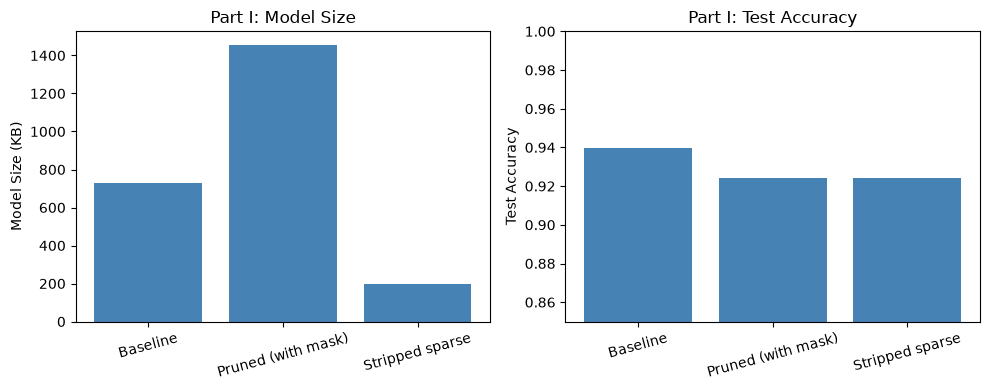

In [50]:
# TODO:
# Plot:
# 1. a bar chart of the Part I model sizes
# 2. a bar chart of the Part I test accuracies

# <-- Enter your code here <--#
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(part1_df["Model"], part1_df["Model Size (KB)"], color="steelblue")
axes[0].set_ylabel("Model Size (KB)")
axes[0].set_title("Part I: Model Size")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(part1_df["Model"], part1_df["Test Accuracy"], color="steelblue")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("Part I: Test Accuracy")
axes[1].set_ylim([0.85, 1.0])
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse Model

Stripped Sparse Model — Classification Report:
                    precision    recall  f1-score   support

           WALKING     0.9848    0.9133    0.9477       496
  WALKING_UPSTAIRS     0.9417    0.9257    0.9336       471
WALKING_DOWNSTAIRS     0.8565    0.9524    0.9019       420
           SITTING     0.9461    0.8228    0.8802       491
          STANDING     0.8358    0.9568    0.8922       532
            LAYING     1.0000    0.9702    0.9849       537

          accuracy                         0.9240      2947
         macro avg     0.9275    0.9235    0.9234      2947
      weighted avg     0.9291    0.9240    0.9244      2947



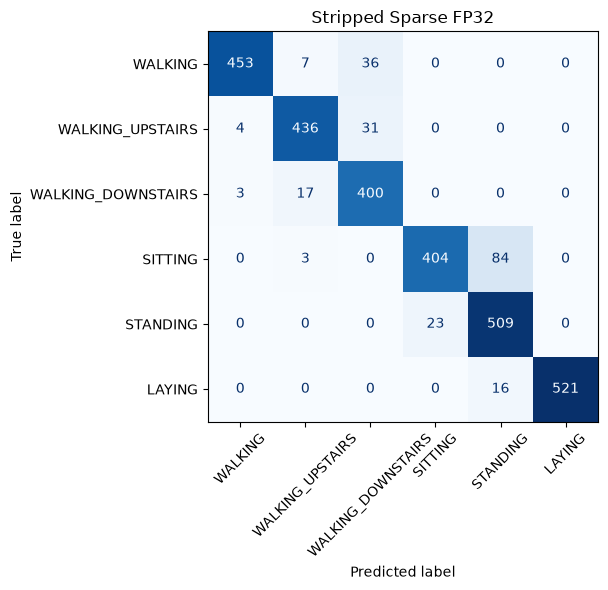

In [51]:
# TODO:
# Plot the confusion matrix for the stripped sparse TFLite model.
# Print the classification report for the stripped sparse TFLite model.

# <-- Enter your code here <--#
print("Stripped Sparse Model — Classification Report:")
print(classification_report(y_test, stripped_sparse_preds, target_names=class_names, digits=4))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_preds),
    display_labels=class_names
).plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
ax.set_title("Stripped Sparse FP32")
plt.tight_layout()
plt.show()

# Part II: Model Pruning + Float16 Quantization

In this part, we combine **pruning** and **float16 quantization**.

We will compare:
1. the pruned TensorFlow Lite model **with** the pruning wrappers still attached, after float16 quantization, and
2. the stripped sparse TensorFlow Lite model after **both** sparsity-aware optimization and float16 quantization.

This lets us observe whether properly finalizing the pruned model leads to a more compact deployable representation.


In [52]:
# TODO:
# Part II: combine pruning and float16 quantization.
#
# 1. Convert the pruned model with mask using:
#    - optimizations = [tf.lite.Optimize.DEFAULT]
#    - supported_types = [tf.float16]
# 2. Save and evaluate the float16 model with mask.
# 3. Convert the stripped sparse model using:
#    - optimizations = [tf.lite.Optimize.DEFAULT, tf.lite.Optimize.EXPERIMENTAL_SPARSITY]
#    - supported_types = [tf.float16]
# 4. Save and evaluate the stripped sparse + float16 model.

# <-- Enter your code here <--#
# Pruned model with mask + float16
conv_fp16_mask = tf.lite.TFLiteConverter.from_keras_model(pruned_model)
conv_fp16_mask.optimizations = [tf.lite.Optimize.DEFAULT]
conv_fp16_mask.target_spec.supported_types = [tf.float16]
pruned_fp16_with_mask_tflite = conv_fp16_mask.convert()

pruned_fp16_with_mask_size_kb = save_binary_model(pruned_fp16_with_mask_tflite, "pruned_with_mask_fp16.tflite")
pruned_fp16_with_mask_acc, pruned_fp16_with_mask_preds = evaluate_tflite_model(
    pruned_fp16_with_mask_tflite, X_test, y_test
)

# Stripped sparse model + float16
conv_fp16_stripped = tf.lite.TFLiteConverter.from_keras_model(stripped_model)
conv_fp16_stripped.optimizations = [
    tf.lite.Optimize.DEFAULT,
    tf.lite.Optimize.EXPERIMENTAL_SPARSITY,
]
conv_fp16_stripped.target_spec.supported_types = [tf.float16]
stripped_sparse_fp16_tflite = conv_fp16_stripped.convert()

stripped_sparse_fp16_size_kb = save_binary_model(stripped_sparse_fp16_tflite, "stripped_sparse_fp16.tflite")
stripped_sparse_fp16_acc, stripped_sparse_fp16_preds = evaluate_tflite_model(
    stripped_sparse_fp16_tflite, X_test, y_test
)

print(f"Pruned FP16 (with mask)  — Accuracy: {pruned_fp16_with_mask_acc:.4f},  Size: {pruned_fp16_with_mask_size_kb:.2f} KB")
print(f"Stripped Sparse FP16     — Accuracy: {stripped_sparse_fp16_acc:.4f},  Size: {stripped_sparse_fp16_size_kb:.2f} KB")

INFO:tensorflow:Assets written to: C:\Users\spappuru\AppData\Local\Temp\tmp5i77kxwj\assets


INFO:tensorflow:Assets written to: C:\Users\spappuru\AppData\Local\Temp\tmp5i77kxwj\assets


INFO:tensorflow:Assets written to: C:\Users\spappuru\AppData\Local\Temp\tmpasx6c3g7\assets


INFO:tensorflow:Assets written to: C:\Users\spappuru\AppData\Local\Temp\tmpasx6c3g7\assets


Pruned FP16 (with mask)  — Accuracy: 0.9240,  Size: 732.66 KB
Stripped Sparse FP16     — Accuracy: 0.9240,  Size: 130.50 KB


## 12. Part II Comparison: Accuracy and Model Size

In [53]:
# TODO:
# Create a Part II comparison DataFrame with the columns:
# Model, Format, Test Accuracy, Model Size (KB)
#
# Include:
# - pruned FP32 with mask
# - stripped sparse FP32
# - pruned float16 with mask
# - stripped sparse float16

# <-- Enter your code here <--#
part2_df = pd.DataFrame([
    {"Model": "Pruned (with mask)", "Format": "FP32",          "Test Accuracy": pruned_with_mask_acc,     "Model Size (KB)": pruned_with_mask_size_kb},
    {"Model": "Stripped sparse",    "Format": "FP32 + Sparse", "Test Accuracy": stripped_sparse_acc,      "Model Size (KB)": stripped_sparse_size_kb},
    {"Model": "Pruned (with mask)", "Format": "FP16",          "Test Accuracy": pruned_fp16_with_mask_acc, "Model Size (KB)": pruned_fp16_with_mask_size_kb},
    {"Model": "Stripped sparse",    "Format": "FP16 + Sparse", "Test Accuracy": stripped_sparse_fp16_acc,  "Model Size (KB)": stripped_sparse_fp16_size_kb},
])

print("Part II — Pruning + Float16 Comparison:")
print(part2_df.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

Part II — Pruning + Float16 Comparison:
             Model        Format  Test Accuracy  Model Size (KB)
Pruned (with mask)          FP32         0.9240        1454.2344
   Stripped sparse FP32 + Sparse         0.9240         196.2812
Pruned (with mask)          FP16         0.9240         732.6641
   Stripped sparse FP16 + Sparse         0.9240         130.5000


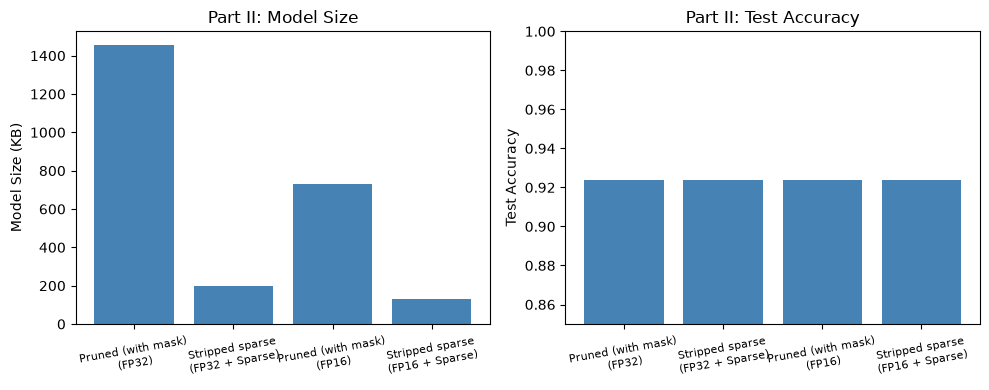

In [54]:
# TODO:
# Plot:
# 1. a bar chart of Part II model sizes
# 2. a bar chart of Part II test accuracies

# <-- Enter your code here <--#
labels2 = [f"{row['Model']}\n({row['Format']})" for _, row in part2_df.iterrows()]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(labels2, part2_df["Model Size (KB)"], color="steelblue")
axes[0].set_ylabel("Model Size (KB)")
axes[0].set_title("Part II: Model Size")
axes[0].tick_params(axis="x", rotation=10, labelsize=8)

axes[1].bar(labels2, part2_df["Test Accuracy"], color="steelblue")
axes[1].set_ylabel("Test Accuracy")
axes[1].set_title("Part II: Test Accuracy")
axes[1].set_ylim([0.85, 1.0])
axes[1].tick_params(axis="x", rotation=10, labelsize=8)

plt.tight_layout()
plt.show()

### Confusion Matrix for the Stripped Sparse + Float16 Model

Stripped Sparse + Float16 — Classification Report:
                    precision    recall  f1-score   support

           WALKING     0.9848    0.9133    0.9477       496
  WALKING_UPSTAIRS     0.9417    0.9257    0.9336       471
WALKING_DOWNSTAIRS     0.8565    0.9524    0.9019       420
           SITTING     0.9461    0.8228    0.8802       491
          STANDING     0.8358    0.9568    0.8922       532
            LAYING     1.0000    0.9702    0.9849       537

          accuracy                         0.9240      2947
         macro avg     0.9275    0.9235    0.9234      2947
      weighted avg     0.9291    0.9240    0.9244      2947



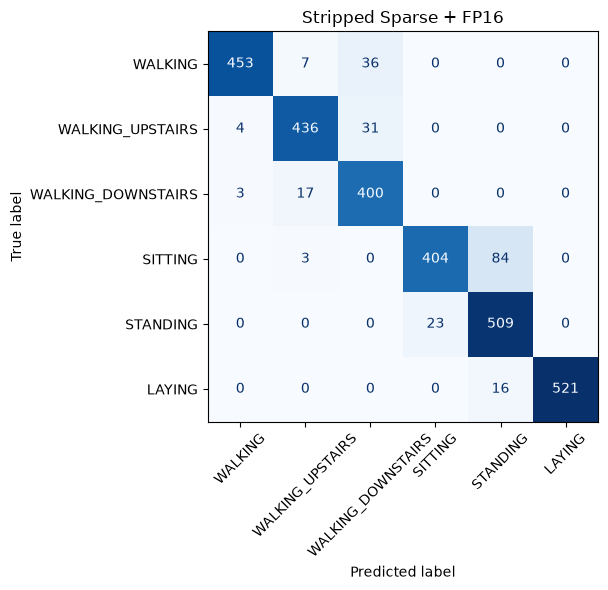

In [55]:
# TODO:
# Plot the confusion matrix for the stripped sparse + float16 TFLite model.
# Print the classification report for the stripped sparse + float16 TFLite model.

# <-- Enter your code here <--#

print("Stripped Sparse + Float16 — Classification Report:")
print(classification_report(y_test, stripped_sparse_fp16_preds, target_names=class_names, digits=4))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, stripped_sparse_fp16_preds),
    display_labels=class_names
).plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
ax.set_title("Stripped Sparse + FP16")
plt.tight_layout()
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Did pruning alone reduce the TensorFlow Lite file size when the pruning wrappers were still attached?
    The pruning alone actually made the file larger because it isn't compressed. 
   
3. Why does `strip_pruning(...)` matter before export?
    strip_pruning removes the wrapper layers, and collapses then into a plain dense layer. Once stripped, the tflite converter then can recognize the zero pattern and then encode the weights into compressed format.
   
5. Which model had the smallest file size in this notebook?

The model that had the smallest file size in this notebook was definetely the stripped + FP16 model which had a size of around 224 KB. 
   
7. Did float16 quantization noticeably change the test accuracy?

No the accuracy was practically the same across all. 
   
9. If you were deploying this model on a resource-constrained device, which version would you choose and why?

The stripped sparse + FP 16 model is definetely the one I'd use because it is the most efficient for devices with limited storage. 

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- output cells or screenshots showing the comparison tables,
- confusion matrices for the baseline model and your final highlighted compressed model,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors using the **`Python (tinyml-arduino)`** kernel.
